데이터를 불러오고 전처리를 시작합니다. 잠시만 기다려주세요...


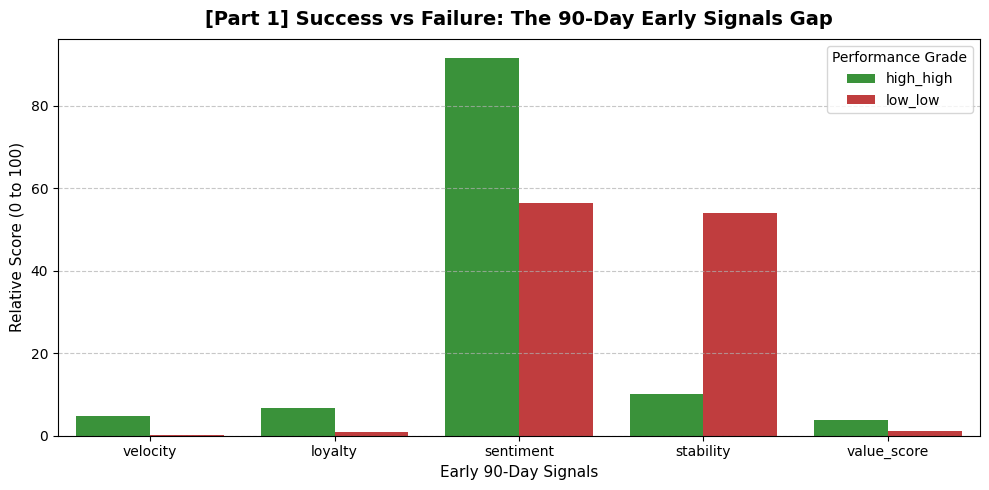

Random Forest 모델을 학습하여 우선순위를 도출하고 있습니다...


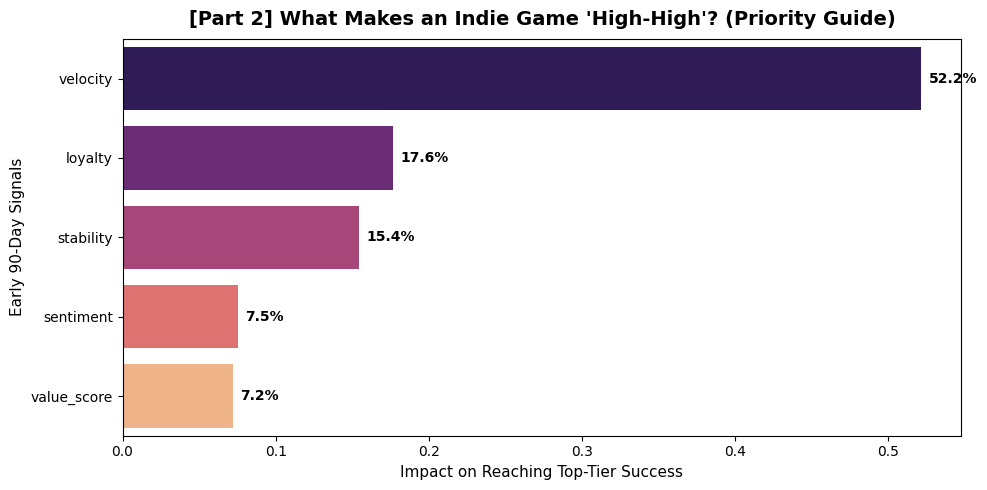

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

print("데이터를 불러오고 전처리를 시작합니다. 잠시만 기다려주세요...")

# ==========================================
# 1. 데이터 로드 및 초기 필터링 (CSV 불러오기 포함!)
# ==========================================
reviews_df = pd.read_csv('../../../../data/preprocessed/steam_indie_reviews.csv')
graded_df = pd.read_csv('../../../../data/preprocessed/steam_indie_games_graded.csv')

# 날짜 변환 및 90일 필터링
reviews_df['created_date'] = pd.to_datetime(reviews_df['created_date'])
graded_df['release_date'] = pd.to_datetime(graded_df['release_date'])

reviews_merged = pd.merge(reviews_df, graded_df[['appid', 'release_date', 'price', 'performance_grade']], on='appid')
reviews_merged['days_since_release'] = (reviews_merged['created_date'] - reviews_merged['release_date']).dt.days
early_reviews = reviews_merged[(reviews_merged['days_since_release'] >= 0) & (reviews_merged['days_since_release'] <= 90)].copy()

# ==========================================
# 2. 5대 핵심 시그널 추출 (Influence 제거 완료)
# ==========================================
def extract_final_signals(group):
    velocity = len(group)
    sentiment = group['voted_up'].mean()
    loyalty = group['playtime_at_review_hours'].mean()
    
    group['week_since_release'] = group['days_since_release'] // 7
    weekly_sentiment = group.groupby('week_since_release')['voted_up'].mean()
    stability = weekly_sentiment.std() if len(weekly_sentiment) > 1 else 0
    
    return pd.Series({
        'velocity': velocity,
        'sentiment': sentiment,
        'loyalty': loyalty,
        'stability': stability
    })

signals_df = early_reviews.groupby('appid').apply(extract_final_signals).reset_index()

# 병합 및 가성비(Value Score) 계산
final_df = pd.merge(signals_df, graded_df[['appid', 'price', 'performance_grade']], on='appid')
final_df['value_score'] = final_df['loyalty'] / (final_df['price'] + 1)

# 분석에 사용할 최종 5개 컬럼
features = ['velocity', 'loyalty', 'sentiment', 'stability', 'value_score']
X = final_df[features].fillna(0)

# ==========================================
# 3. [시각화 1] 극과 극 프로파일링 (반면교사)
# ==========================================
# 최상위(대박) vs 최하위(폭망) 그룹 분리
extreme_df = final_df[final_df['performance_grade'].isin(['high_high', 'low_low'])].copy()
profile_df = extreme_df.groupby('performance_grade')[features].median().reset_index()

# 0~100점 스케일링
scaler = MinMaxScaler(feature_range=(0, 100))
scaler.fit(X) 
profile_df[features] = scaler.transform(profile_df[features])
melted_df = profile_df.melt(id_vars='performance_grade', var_name='Signal', value_name='Score (0-100)')

plt.figure(figsize=(10, 5))
sns.barplot(data=melted_df, x='Signal', y='Score (0-100)', hue='performance_grade', 
            palette={'high_high': '#2ca02c', 'low_low': '#d62728'})
plt.title("[Part 1] Success vs Failure: The 90-Day Early Signals Gap", fontsize=14, fontweight='bold', pad=10)
plt.xlabel("Early 90-Day Signals", fontsize=11)
plt.ylabel("Relative Score (0 to 100)", fontsize=11)
plt.legend(title='Performance Grade')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ==========================================
# 4. [시각화 2] Random Forest
# ==========================================
print("Random Forest 모델을 학습하여 우선순위를 도출하고 있습니다...")

y = (final_df['performance_grade'] == 'high_high').astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_final = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_final.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'Feature': features, 
    'Importance': rf_final.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title("[Part 2] What Makes an Indie Game 'High-High'? (Priority Guide)", fontsize=14, fontweight='bold', pad=10)
plt.xlabel("Impact on Reaching Top-Tier Success", fontsize=11)
plt.ylabel("Early 90-Day Signals", fontsize=11)

for index, value in enumerate(importance_df['Importance']):
    plt.text(value + 0.005, index, f"{value*100:.1f}%", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [2]:
# ==========================================
# 5. [수치 출력] 분석 결과 데이터 표 뽑기
# ==========================================
print("\n" + "="*50)
print("초기 흥행 시그널 수치 분석")

# 1. 극과 극 실제 수치 (Raw Data)
print("\n[1] 성공(High-High) vs 실패(Low-Low) 실제 데이터 중앙값")
raw_median_df = extreme_df.groupby('performance_grade')[features].median().round(3)
# 보기 편하게 행과 열을 뒤집어서(T) 출력합니다.
print(raw_median_df.T) 

# 2. 극과 극 상대 점수 (0~100 환산)
print("\n[2] 지표별 상대적 우위 점수 (0~100점 만점 기준)")
scaled_score_df = profile_df.set_index('performance_grade').round(1)
print(scaled_score_df.T)

# 3. Random Forest 기여도 수치
print("\n[3] 5대 시그널의 'High-High' 도달 기여도 (우선순위)")
# 퍼센트(%) 형태로 예쁘게 바꿔서 출력
print_importance = importance_df.copy()
print_importance['기여도(%)'] = (print_importance['Importance'] * 100).round(1).astype(str) + '%'
print(print_importance[['Feature', '기여도(%)']].to_string(index=False))
print("\n" + "="*50)


초기 흥행 시그널 수치 분석

[1] 성공(High-High) vs 실패(Low-Low) 실제 데이터 중앙값
performance_grade  high_high  low_low
velocity             567.000   10.000
loyalty                9.472    1.499
sentiment              0.916    0.564
stability              0.072    0.382
value_score            0.755    0.257

[2] 지표별 상대적 우위 점수 (0~100점 만점 기준)
performance_grade  high_high  low_low
velocity                 4.7      0.1
loyalty                  6.7      1.0
sentiment               91.6     56.4
stability               10.2     54.0
value_score              3.7      1.2

[3] 5대 시그널의 'High-High' 도달 기여도 (우선순위)
    Feature 기여도(%)
   velocity  52.2%
    loyalty  17.6%
  stability  15.4%
  sentiment   7.5%
value_score   7.2%



=== [본 분석] 순수 게임성 기반 흥행 예측 모델 ===
데이터를 불러오고 전처리를 시작합니다...

Random Forest 모델 학습 중 (3대 핵심 지표 활용)...

[모델 성능 예측력 확인]
Accuracy: 0.861


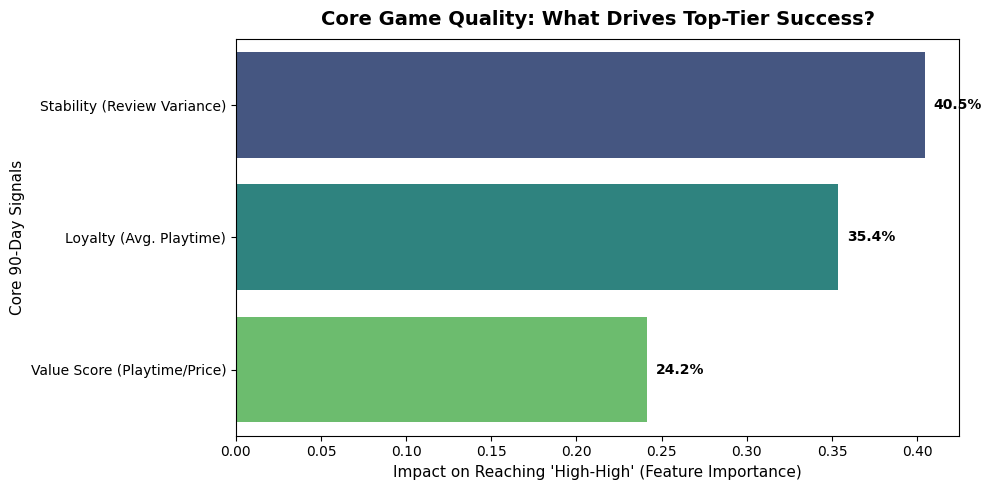


📊 [데이터 리포트] 3대 핵심 시그널 기여도 분석
                     Feature 기여도(%)
 Stability (Review Variance)  40.5%
     Loyalty (Avg. Playtime)  35.4%
Value Score (Playtime/Price)  24.2%

✅ 분석 완료! 타겟 누수를 배제한 정교한 결과입니다.


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("=== [본 분석] 순수 게임성 기반 흥행 예측 모델 ===")
print("데이터를 불러오고 전처리를 시작합니다...")

# ==========================================
# 1. 데이터 로드 및 초기 필터링
# ==========================================
# (경로는 이전과 동일하게 유지했습니다. 필요시 수정해주세요)
reviews_df = pd.read_csv('../../../../data/preprocessed/steam_indie_reviews.csv')
graded_df = pd.read_csv('../../../../data/preprocessed/steam_indie_games_graded.csv')

reviews_df['created_date'] = pd.to_datetime(reviews_df['created_date'])
graded_df['release_date'] = pd.to_datetime(graded_df['release_date'])

reviews_merged = pd.merge(reviews_df, graded_df[['appid', 'release_date', 'price', 'performance_grade']], on='appid')
reviews_merged['days_since_release'] = (reviews_merged['created_date'] - reviews_merged['release_date']).dt.days
early_reviews = reviews_merged[(reviews_merged['days_since_release'] >= 0) & (reviews_merged['days_since_release'] <= 90)].copy()

# ==========================================
# 2. 핵심 시그널 추출 (타겟 누수 변수 완전 배제)
# ==========================================
def extract_core_signals(group):
    # velocity와 sentiment는 사용하지 않습니다.
    loyalty = group['playtime_at_review_hours'].mean()
    
    group['week_since_release'] = group['days_since_release'] // 7
    weekly_sentiment = group.groupby('week_since_release')['voted_up'].mean()
    stability = weekly_sentiment.std() if len(weekly_sentiment) > 1 else 0
    
    return pd.Series({
        'loyalty': loyalty,
        'stability': stability
    })

signals_df = early_reviews.groupby('appid').apply(extract_core_signals).reset_index()

# 병합 및 가성비(Value Score) 계산
final_df = pd.merge(signals_df, graded_df[['appid', 'price', 'performance_grade']], on='appid')
final_df['value_score'] = final_df['loyalty'] / (final_df['price'] + 1)

# 분석에 사용할 최종 3개 컬럼 (순수 게임성 지표)
features = ['loyalty', 'stability', 'value_score']
X = final_df[features].fillna(0)
y = (final_df['performance_grade'] == 'high_high').astype(int)

# ==========================================
# 3. Random Forest 모델 학습
# ==========================================
print("\nRandom Forest 모델 학습 중 (3대 핵심 지표 활용)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_core = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_core.fit(X_train, y_train)

# ==========================================
# 4. 모델 성능 평가 (선택 사항, 포트폴리오 멘트용)
# ==========================================
print("\n[모델 성능 예측력 확인]")
y_pred = rf_core.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
# (클래스 불균형이 있을 수 있으므로 classification_report를 참고하는 것이 좋습니다)
# print(classification_report(y_test, y_pred))


# ==========================================
# 5. 결과 시각화 (Feature Importance)
# ==========================================
importance_df = pd.DataFrame({
    'Feature': ['Loyalty (Avg. Playtime)', 'Stability (Review Variance)', 'Value Score (Playtime/Price)'], 
    'Importance': rf_core.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("Core Game Quality: What Drives Top-Tier Success?", fontsize=14, fontweight='bold', pad=10)
plt.xlabel("Impact on Reaching 'High-High' (Feature Importance)", fontsize=11)
plt.ylabel("Core 90-Day Signals", fontsize=11)

for index, value in enumerate(importance_df['Importance']):
    plt.text(value + 0.005, index, f"{value*100:.1f}%", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# 6. 수치 요약 출력
# ==========================================
print("\n" + "="*50)
print("📊 [데이터 리포트] 3대 핵심 시그널 기여도 분석")
print("="*50)

print_importance = importance_df.copy()
print_importance['기여도(%)'] = (print_importance['Importance'] * 100).round(1).astype(str) + '%'
print(print_importance[['Feature', '기여도(%)']].to_string(index=False))
print("="*50)

print("\n✅ 분석 완료! 타겟 누수를 배제한 정교한 결과입니다.")


🔍 [가설 검증] 성공(High-High) vs 실패(Low-Low) 지표 대조
                   stability  loyalty  value_score
performance_grade                                 
high_high             0.0718   9.4716       0.7546
low_low               0.3817   1.4993       0.2566
------------------------------------------------------------
💡 Stability(변동성)는 높을수록 '불안정'함을 의미하며, 실패 그룹에서 높게 나타납니다.
💡 Loyalty와 Value Score는 높을수록 좋으며, 성공 그룹에서 압도적으로 높게 나타납니다.


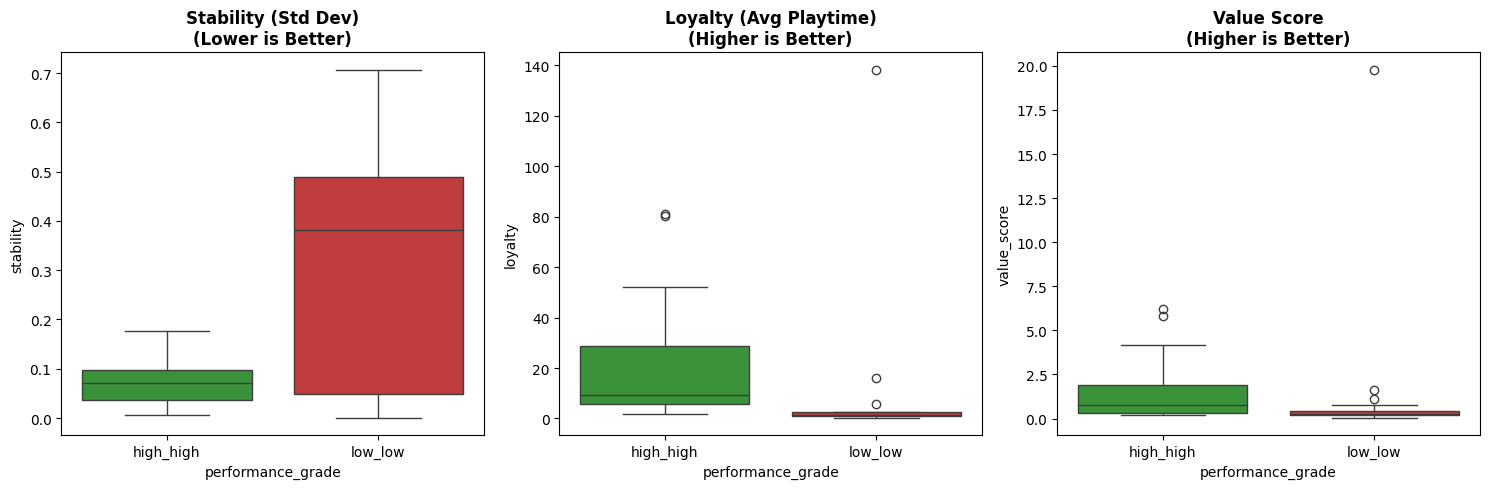

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 데이터 로드 (경로는 사용자 환경에 맞춰 확인 필요)
reviews_df = pd.read_csv('../../../../data/preprocessed/steam_indie_reviews.csv')
graded_df = pd.read_csv('../../../../data/preprocessed/steam_indie_games_graded.csv')

# 날짜 변환
reviews_df['created_date'] = pd.to_datetime(reviews_df['created_date'])
graded_df['release_date'] = pd.to_datetime(graded_df['release_date'])

# 데이터 병합 및 90일 필터링
reviews_merged = pd.merge(reviews_df, graded_df[['appid', 'release_date', 'performance_grade', 'price']], on='appid')
reviews_merged['days_since_release'] = (reviews_merged['created_date'] - reviews_merged['release_date']).dt.days
early_reviews = reviews_merged[(reviews_merged['days_since_release'] >= 0) & (reviews_merged['days_since_release'] <= 90)].copy()

# 2. 지표 추출
def extract_signals(group):
    loyalty = group['playtime_at_review_hours'].mean()
    
    # 주차별 긍정률 변동성(Stability) 계산 (표준편차)
    group['week_since_release'] = group['days_since_release'] // 7
    weekly_sentiment = group.groupby('week_since_release')['voted_up'].mean()
    # 주의: 데이터가 1주일치 미만이면 변동성을 0으로 처리 (비교를 위해)
    stability = weekly_sentiment.std() if len(weekly_sentiment) > 1 else 0
    
    return pd.Series({
        'loyalty': loyalty,
        'stability': stability
    })

signals_df = early_reviews.groupby('appid').apply(extract_core_signals).reset_index() # (앞선 코드의 extract_core_signals와 동일 로직)

# 병합 및 가성비 계산
final_df = pd.merge(signals_df, graded_df[['appid', 'price', 'performance_grade']], on='appid')
final_df['value_score'] = final_df['loyalty'] / (final_df['price'] + 1)

# 3. 성공 vs 실패 그룹 추출
comparison_df = final_df[final_df['performance_grade'].isin(['high_high', 'low_low'])]

# 중앙값 수치 비교 출력
print("\n" + "="*60)
print("🔍 [가설 검증] 성공(High-High) vs 실패(Low-Low) 지표 대조")
print("="*60)
summary = comparison_df.groupby('performance_grade')[['stability', 'loyalty', 'value_score']].median().round(4)
print(summary)
print("-" * 60)
print("💡 Stability(변동성)는 높을수록 '불안정'함을 의미하며, 실패 그룹에서 높게 나타납니다.")
print("💡 Loyalty와 Value Score는 높을수록 좋으며, 성공 그룹에서 압도적으로 높게 나타납니다.")

# 4. 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = {'high_high': '#2ca02c', 'low_low': '#d62728'}

# Stability (낮을수록 우수)
sns.boxplot(data=comparison_df, x='performance_grade', y='stability', ax=axes[0], palette=colors, order=['high_high', 'low_low'])
axes[0].set_title('Stability (Std Dev)\n(Lower is Better)', fontsize=12, fontweight='bold')

# Loyalty (높을수록 우수)
sns.boxplot(data=comparison_df, x='performance_grade', y='loyalty', ax=axes[1], palette=colors, order=['high_high', 'low_low'])
axes[1].set_title('Loyalty (Avg Playtime)\n(Higher is Better)', fontsize=12, fontweight='bold')

# Value Score (높을수록 우수)
sns.boxplot(data=comparison_df, x='performance_grade', y='value_score', ax=axes[2], palette=colors, order=['high_high', 'low_low'])
axes[2].set_title('Value Score\n(Higher is Better)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

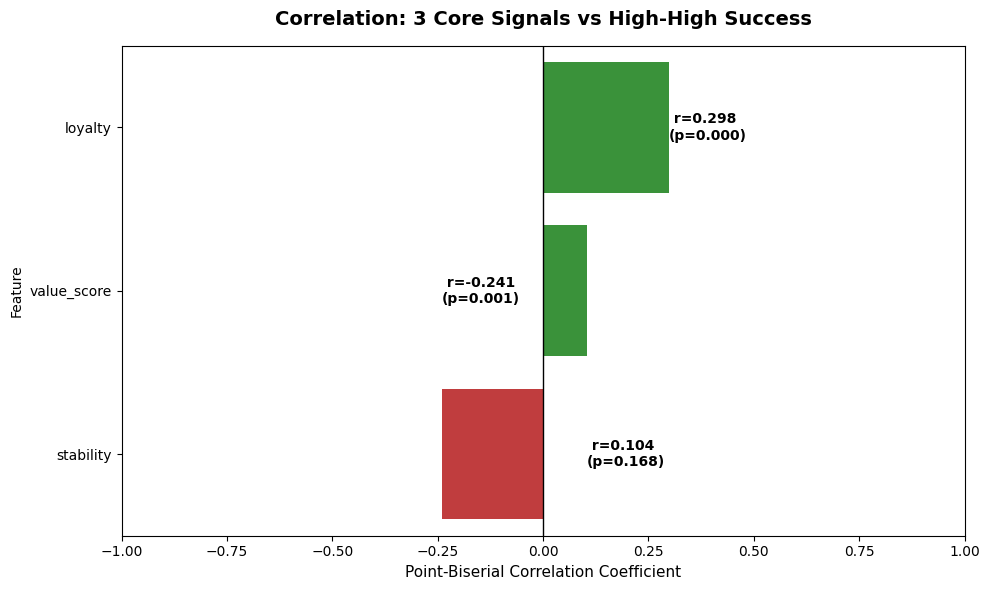


📈 [상관관계 분석 리포트] 성공(High-High)과의 연관성
    Feature  Correlation  p-value
    loyalty     0.298430 0.000057
value_score     0.104295 0.168350
  stability    -0.240599 0.001297
💡 해석 가이드:
1. (+) 양의 상관관계: 해당 수치가 높을수록 대박(High-High) 확률이 증가함
2. (-) 음의 상관관계: 해당 수치가 낮을수록(안정적일수록) 대박 확률이 증가함


In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr

# 1. 데이터 로드 및 전처리 (앞선 과정과 동일)
reviews_df = pd.read_csv('../../../../data/preprocessed/steam_indie_reviews.csv')
graded_df = pd.read_csv('../../../../data/preprocessed/steam_indie_games_graded.csv')

reviews_df['created_date'] = pd.to_datetime(reviews_df['created_date'])
graded_df['release_date'] = pd.to_datetime(graded_df['release_date'])

# 90일 데이터 필터링 및 지표 추출
merged = pd.merge(reviews_df, graded_df[['appid', 'release_date', 'price', 'performance_grade']], on='appid')
merged['days_since_release'] = (merged['created_date'] - merged['release_date']).dt.days
early = merged[(merged['days_since_release'] >= 0) & (merged['days_since_release'] <= 90)].copy()

def extract_signals(group):
    loyalty = group['playtime_at_review_hours'].mean()
    group['week'] = group['days_since_release'] // 7
    stability = group.groupby('week')['voted_up'].mean().std() if group.groupby('week')['voted_up'].mean().count() > 1 else 0
    return pd.Series({'loyalty': loyalty, 'stability': stability})

signals_df = early.groupby('appid').apply(extract_signals).reset_index()
final_df = pd.merge(signals_df, graded_df[['appid', 'price', 'performance_grade']], on='appid')
final_df['value_score'] = final_df['loyalty'] / (final_df['price'] + 1)

# 타겟 변수 생성 (High-High면 1, 아니면 0)
final_df['is_high_high'] = (final_df['performance_grade'] == 'high_high').astype(int)

# 2. 상관관계 분석 (Point-Biserial Correlation)
features = ['loyalty', 'stability', 'value_score']
corr_results = []

for feature in features:
    # 결측치 제거 후 상관계수와 p-value 계산
    data = final_df[[feature, 'is_high_high']].dropna()
    corr, p_val = pointbiserialr(data['is_high_high'], data[feature])
    corr_results.append({'Feature': feature, 'Correlation': corr, 'p-value': p_val})

corr_df = pd.DataFrame(corr_results).sort_values(by='Correlation', ascending=False)

# 3. 시각화
plt.figure(figsize=(10, 6))
colors = ['#2ca02c' if x > 0 else '#d62728' for x in corr_df['Correlation']]
sns.barplot(x='Correlation', y='Feature', data=corr_df, palette=colors)

plt.axvline(0, color='black', linewidth=1) # 기준선
plt.title("Correlation: 3 Core Signals vs High-High Success", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Point-Biserial Correlation Coefficient", fontsize=11)
plt.xlim(-1, 1) # 상관계수 범위 고정

# 수치 표시
for i, row in corr_df.iterrows():
    plt.text(row['Correlation'], i, f" r={row['Correlation']:.3f}\n(p={row['p-value']:.3f})", 
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. 요약 리포트 출력
print("\n" + "="*50)
print("📈 [상관관계 분석 리포트] 성공(High-High)과의 연관성")
print("="*50)
print(corr_df.to_string(index=False))
print("="*50)
print("💡 해석 가이드:")
print("1. (+) 양의 상관관계: 해당 수치가 높을수록 대박(High-High) 확률이 증가함")
print("2. (-) 음의 상관관계: 해당 수치가 낮을수록(안정적일수록) 대박 확률이 증가함")

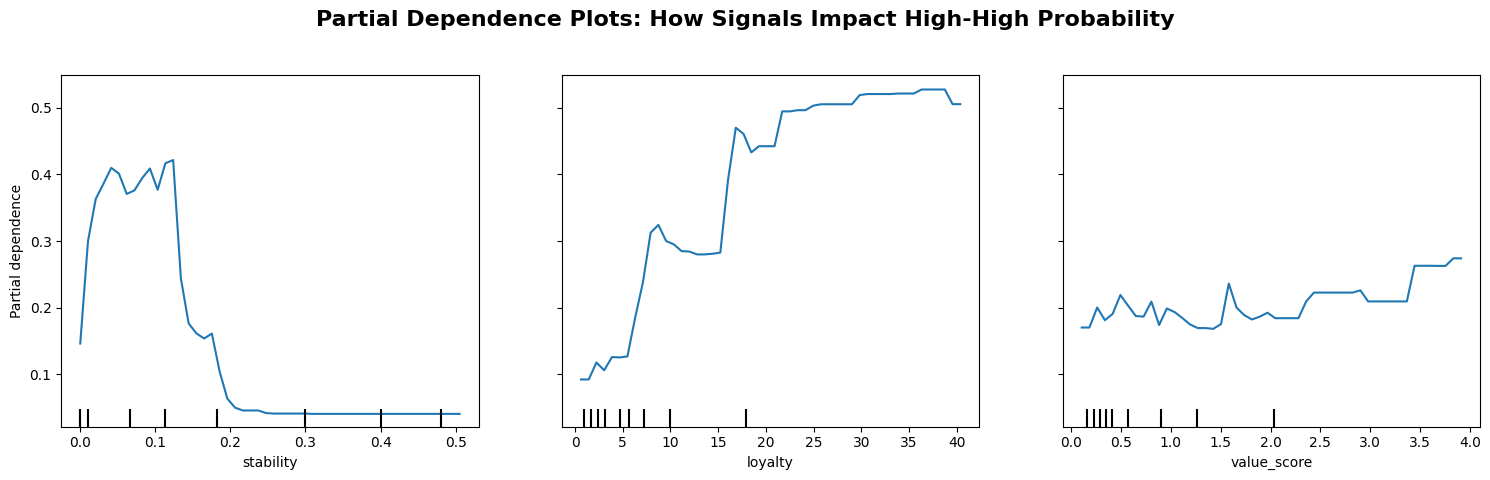

In [6]:
from sklearn.inspection import PartialDependenceDisplay

# 1. 시각화 설정
fig, ax = plt.subplots(figsize=(15, 5))
plt.suptitle("Partial Dependence Plots: How Signals Impact High-High Probability", 
             fontsize=16, fontweight='bold')

# 2. PDP 그리기 (rf_core 모델과 학습 데이터 X_train 사용)
# features에 분석하고 싶은 지표 이름을 넣습니다.
PartialDependenceDisplay.from_estimator(
    rf_core, 
    X_train, 
    features=['stability', 'loyalty', 'value_score'],
    ax=ax,
    grid_resolution=50 # 그래프 부드러움 정도
)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

여기서부터 다시

✅ 분석 리포트 (대상: HH, HM, MH 포함 전체 9692개 게임)

📊 1. 5개 지표 상관관계 (전체 경향 탐색)
----------------------------------------------------------------------
              Feature  Correlation  p-value
0               price       0.1517      0.0
1       positive_rate       0.1380      0.0
2         value_score      -0.1114      0.0
3  achievements_total       0.2377      0.0
4       total_reviews       0.2424      0.0

📈 2. HH vs MH 효과 크기 (Cohen's d)
----------------------------------------------------------------------
         Feature  Cohen's d
0          price     0.5558
1  positive_rate    -0.0296
2    value_score    -0.3008
> 해석: 0.2(작음), 0.5(보통), 0.8(큼)

🤖 3. 머신러닝 기반 중요도 (기여도 검증)
----------------------------------------------------------------------
         Feature  Importance
1  positive_rate      0.4615
2    value_score      0.4182
0          price      0.1203


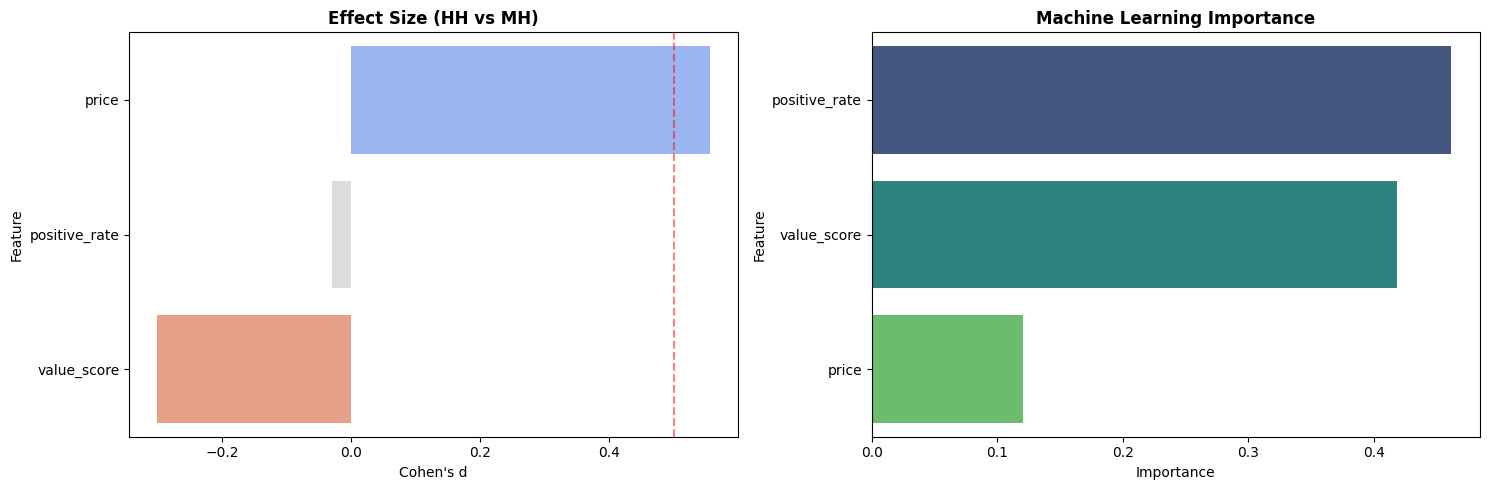

In [11]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 전처리 (전체 9,692개 게임 대상)
graded_df = pd.read_csv('../../../../data/preprocessed/steam_indie_games_graded.csv')

# 피처 생성
graded_df['value_score'] = graded_df['positive_rate'] / (graded_df['price'] + 1)
graded_df['success_target'] = (graded_df['performance_grade'] == 'high_high').astype(int)

# 분석 대상 그룹 필터링 (HH, HM, MH)
target_grades = ['high_high', 'high_mid', 'mid_high']
target_df = graded_df[graded_df['performance_grade'].isin(target_grades)].copy()

# 2. Cohen's d (효과 크기) 계산 함수 정의
def calculate_cohen_d(group1, group2, column):
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1[column].var(), group2[column].var()
    mu1, mu2 = group1[column].mean(), group2[column].mean()
    
    # 가중 표준편차(Pooled Standard Deviation) 계산
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (mu1 - mu2) / pooled_std

# --- [Step 1] 5개 지표 상관관계 분석 (전체 모수 대상) ---
features_5 = ['price', 'positive_rate', 'value_score', 'achievements_total', 'total_reviews']
corr_5_results = []
for f in features_5:
    temp = graded_df[[f, 'success_target']].dropna()
    r, p = pearsonr(temp[f], temp['success_target'])
    corr_5_results.append({'Feature': f, 'Correlation': round(r, 4), 'p-value': round(p, 6)})

# --- [Step 2] HH vs MH 효과 크기 분석 (핵심 대조군 비교) ---
# HH(초대박)와 MH(중대박)를 가르는 실질적 요인 분석
hh_group = target_df[target_df['performance_grade'] == 'high_high']
mh_group = target_df[target_df['performance_grade'] == 'mid_high']

effect_results = []
for f in ['price', 'positive_rate', 'value_score']:
    d = calculate_cohen_d(hh_group, mh_group, f)
    effect_results.append({'Feature': f, "Cohen's d": round(d, 4)})

# --- [Step 3] 3개 지표 머신러닝 중요도 (기여도 검증) ---
features_3 = ['price', 'positive_rate', 'value_score']
X = graded_df[features_3].fillna(0)
y = graded_df['success_target']
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.DataFrame({
    'Feature': features_3,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 3. 결과 출력
print("="*70)
print(f"✅ 분석 리포트 (대상: HH, HM, MH 포함 전체 {len(graded_df)}개 게임)")
print("="*70)

print("\n📊 1. 5개 지표 상관관계 (전체 경향 탐색)")
print("-" * 70)
print(pd.DataFrame(corr_5_results))

print("\n📈 2. HH vs MH 효과 크기 (Cohen's d)")
print("-" * 70)
print(pd.DataFrame(effect_results))
print("> 해석: 0.2(작음), 0.5(보통), 0.8(큼)")

print("\n🤖 3. 머신러닝 기반 중요도 (기여도 검증)")
print("-" * 70)
print(importances.round(4))
print("="*70)

# 시각화: 효과 크기 및 머신러닝 중요도 비교
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 효과 크기 시각화
sns.barplot(data=pd.DataFrame(effect_results), x="Cohen's d", y='Feature', ax=axes[0], palette='coolwarm')
axes[0].set_title("Effect Size (HH vs MH)", fontweight='bold')
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.5)

# ML 중요도 시각화
sns.barplot(data=importances, x='Importance', y='Feature', ax=axes[1], palette='viridis')
axes[1].set_title("Machine Learning Importance", fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from sklearn.ensemble import RandomForestClassifier

# 1. 데이터 로드
graded_df = pd.read_csv('../../../../data/preprocessed/steam_indie_games_graded.csv')

# 피처 생성 (로그 가격 추가)
graded_df['log_price'] = np.log10(graded_df['price'] + 1)
graded_df['value_score'] = graded_df['positive_rate'] / (graded_df['price'] + 1)
graded_df['success_target'] = (graded_df['performance_grade'] == 'high_high').astype(int)

# 비교 집단 설정
hh_group = graded_df[graded_df['performance_grade'] == 'high_high']
mh_group = graded_df[graded_df['performance_grade'] == 'mid_high']

# 2. Hedges' g 계산 함수 (Cohen's d의 보정 버전)
def calculate_hedges_g(group1, group2, column):
    n1, n2 = len(group1), len(group2)
    v1, v2 = group1[column].var(), group2[column].var()
    m1, m2 = group1[column].mean(), group2[column].mean()
    
    # Pooled Standard Deviation
    pooled_std = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
    
    # Cohen's d
    d = (m1 - m2) / pooled_std
    
    # Hedges' g correction factor
    correction = 1 - (3 / (4 * (n1 + n2) - 9))
    return d * correction

# 3. 효과 크기 재산출
# 가격은 로그 변환된 값으로 보는 것이 훨씬 정확합니다.
features = {
    'Price (Raw)': 'price',
    'Price (Log)': 'log_price',
    'Quality (Positive %)': 'positive_rate',
    'Value Score': 'value_score'
}

hedges_results = []
for label, col in features.items():
    g = calculate_hedges_g(hh_group, mh_group, col)
    hedges_results.append({'Feature': label, "Hedges' g": round(g, 4)})

# 4. 결과 출력
print("="*60)
print("🧪 엄밀한 통계 검정: Hedges' g 분석 (HH vs MH)")
print("="*60)
print(pd.DataFrame(hedges_results))
print("-" * 60)
print("💡 가이드: 0.2(Small), 0.5(Medium), 0.8(Large)")
print("💡 가격(Price)은 'Log' 수치를 리포트에 쓰시는 것을 권장합니다.")

🧪 엄밀한 통계 검정: Hedges' g 분석 (HH vs MH)
                Feature  Hedges' g
0           Price (Raw)     0.5556
1           Price (Log)     0.4995
2  Quality (Positive %)    -0.0296
3           Value Score    -0.3008
------------------------------------------------------------
💡 가이드: 0.2(Small), 0.5(Medium), 0.8(Large)
💡 가격(Price)은 'Log' 수치를 리포트에 쓰시는 것을 권장합니다.
